# Environment Setup & Dataset Paths


This cell initializes the working environment for the research pipeline:

- Imports core libraries (NumPy, OpenCV, Matplotlib, Pandas) and helpers.

- Enables colored console output via `colorama` for readable logs.

- Imports local modules: `image_processing` (preprocessing/segmentation), `feature_extraction` (ABCD/T, FFT, BWV), `utils` (visualization/metrics), and `config` (tunable parameters).

- Sets Matplotlib defaults for consistent figures.

- Defines PH2 sample image and ground-truth paths. Adjust these to switch cases.



Note: This notebook is research-oriented and not a clinical device. Findings should be validated by experts and against labeled datasets.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tabulate
import pandas as pd
from colorama import init, Fore, Back, Style
from tabulate import tabulate
from colorama import Fore, Style

# Initialize colorama for colored output
init(autoreset=True)

# Import our custom modules
import image_processing as ip
import feature_extraction as fe
import utils
import config

# Set matplotlib parameters for better visualization
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# PH2 Dataset Configuration
sample_image_path = r"C:\Users\Aakarsh Goyal\Downloads\archive\PH2Dataset\PH2 Dataset images\IMD427\IMD427_Dermoscopic_Image\IMD427.bmp" 
ground_truth_mask_path = r"C:\Users\Aakarsh Goyal\Downloads\archive\PH2Dataset\PH2 Dataset images\IMD427\IMD427_lesion\IMD427_lesion.bmp" 

# PH2 Ground-Truth Mask Loading: Concepts and Pitfalls


This code defines `load_ph2_mask(mask_path)` to prepare ground-truth masks for evaluation:

- Reads the PH2 lesion mask in grayscale and checks for loading errors.

- Computes bright vs dark pixel counts to infer whether the lesion is white or black.

- Inverts the mask if needed so convention is consistent: lesion = white (255), background = black (0).

- Binarizes using a stable threshold to remove mid-gray artifacts.

- Prints basic shape and coverage to quickly sanity-check masks.



Why this matters: PH2 masks can be inverted depending on export; consistent polarity avoids metric mistakes (e.g., flipped Dice/IoU).

In [ ]:
def load_ph2_mask(mask_path):
    """
    Load and normalize a PH2 ground-truth lesion mask for evaluation.

    Conceptual overview:
    - PH2 masks can appear with inverted polarity depending on export; this function enforces a
      consistent convention where lesion pixels are white (255) and background is black (0).
    - Robustness comes from measuring bright vs. dark pixel counts and inverting when appropriate,
      then binarizing to eliminate mid-gray artifacts.

    Args:
        mask_path (str): Filesystem path to the PH2 lesion ground-truth mask (BMP/PNG).

    Returns:
        np.ndarray: A uint8 binary mask of shape H×W with values in {0, 255}, where 255 denotes lesion.

    Raises:
        ValueError: If the mask cannot be loaded from the provided path.

    Notes:
        - Enforcing a consistent polarity prevents erroneous metric calculations (e.g., Dice/IoU)
          that can arise from inverted labels.
        - This function does not resize; downstream code should resize to `config.IMAGE_SIZE`
          to align with the processing pipeline.
    """
    # Load mask as grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is None:
        raise ValueError(f"Could not load mask from {mask_path}")
    
    # Check if mask needs inversion (PH2 masks are sometimes inverted)
    # Lesion regions should be white (255), background black (0)
    lesion_pixels = np.sum(mask > 128)  # Count bright pixels
    background_pixels = np.sum(mask <= 128)  # Count dark pixels
    
    # If there are more dark pixels than bright pixels, invert the mask
    if background_pixels > lesion_pixels:
        mask = 255 - mask
        print("🔄 Inverted PH2 mask (lesion regions now white)")
    
    # Ensure binary mask (0 or 255)
    mask = np.where(mask > 128, 255, 0).astype(np.uint8)
    
    print(f"📊 PH2 mask loaded: {mask.shape}")
    # print(f"🔍 Lesion pixels: {np.sum(mask > 0)}")
    print(f"📏 Lesion area: {(np.sum(mask > 0) / mask.size) * 100:.2f}% of image")
    
    return mask

# End-to-End Pipeline: From Preprocessing to Features and GT Alignment


This cell runs the complete analysis pipeline via `main_pipeline()`:

- Color constancy + resizing: prepares `rgb_image`, `hsv_image`, `lab_image`.

- Hair removal: black-hat + inpainting to reduce occlusion artifacts.

- Initial segmentation: color-space heuristics to propose lesion mask.

- GrabCut refinement: graph-cut optimization for cleaner boundaries.

- Feature extraction: ABCD/T, GLCM, FFT high-frequency energy, Blue-White Veil proxy.

- Ground-truth handling: reads, inverts if needed, resizes to `config.IMAGE_SIZE` for apples-to-apples metrics.



Outputs include images, masks, contour, feature dict, and refinement metrics, with error handling for robustness.

In [ ]:
def main_pipeline():
    """Run the complete melanoma analysis pipeline (research-oriented).

    Conceptual stages:
    1) Preprocessing: Load PH2 image; apply color constancy and resizing to standardize input.
    2) Hair removal: Suppress occluding hair via morphological black-hat + inpainting (TELEA).
    3) Initial segmentation: Heuristic color-space thresholding (e.g., Lab/HSV) to propose lesion.
    4) GrabCut refinement: Graph-cut optimization to improve edges and reduce leakage.
    5) Feature extraction: Compute ABC+T, GLCM metrics, FFT high-frequency energy, and BWV proxy.
    6) Ground-truth alignment: Read, polarity-check, and resize GT mask for fair comparisons.

    Returns:
        Tuple[Any, ...]:
            (
                rgb_original_resized (np.ndarray),
                rgb_image (np.ndarray),
                hair_free_image (np.ndarray),
                initial_mask (np.ndarray),
                binary_mask (np.ndarray),
                main_contour (np.ndarray | None),
                features (dict),
                gt_mask_resized (np.ndarray | None),
                grabcut_metrics (dict)
            )

    Error handling:
        - Catches exceptions and prints a readable message; returns Nones/empties for downstream checks.

    Notes:
        - This function is for research and development. It is not a medical device and must be validated
          on labeled datasets by qualified professionals.
    """
    try:
        # Step 1: Load and preprocess (with Gray World color constancy)
        rgb_image, hsv_image, lab_image = ip.load_and_preprocess(sample_image_path)
        
        # Save original image before color correction for comparison
        rgb_original = cv2.cvtColor(cv2.imread(sample_image_path), cv2.COLOR_BGR2RGB)
        rgb_original_resized = cv2.resize(rgb_original, config.IMAGE_SIZE, interpolation=cv2.INTER_LANCZOS4)
        
        # Step 2: Hair removal
        hair_free_image, quality_metrics = ip.remove_hair(rgb_image)
        
        # Step 3: Initial segmentation
        initial_mask, initial_contour, seg_metrics = ip.segment_lesion(hair_free_image)
        
        # Step 4: GrabCut refinement (Advanced DIP)
        binary_mask, main_contour, grabcut_metrics = ip.refine_segmentation_grabcut(
            hair_free_image, initial_mask, initial_contour
)
        
        # Step 5: Feature extraction (including FFT and Blue-White Veil)
        features = fe.extract_all_features(
            original_image=hair_free_image,
            hsv_image=hsv_image,
            mask=binary_mask,
            contour=main_contour
)
        
        # Step 6: Ground truth validation
        gt_mask = cv2.imread(ground_truth_mask_path, cv2.IMREAD_GRAYSCALE)
        
        if gt_mask is not None:
            # Handle PH2 mask inversion
            lesion_pixels_gt = np.sum(gt_mask > 128)
            background_pixels_gt = np.sum(gt_mask <= 128)
            if background_pixels_gt > lesion_pixels_gt:
                gt_mask = 255 - gt_mask
            
            gt_mask_resized = cv2.resize(gt_mask, config.IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)

        return rgb_original_resized, rgb_image, hair_free_image, initial_mask, binary_mask, main_contour, features, gt_mask_resized, grabcut_metrics

    except Exception as e:
        print(f"{Fore.RED}❌ Error in enhanced pipeline: {e}{Style.RESET_ALL}")
        return None, None, None, None, None, None, None, None, {}

rgb_original_resized, rgb_image, hair_free_image, initial_mask, binary_mask, main_contour, features, gt_mask_resized, grabcut_metrics = main_pipeline()


# Preprocessing Visualization: Original → Hair-Free → Lesion Overlay


This visualization cell creates a quick triage view:

- Original dermoscopic image (for context and acquisition quality checks).

- Hair-free image to confirm artifact suppression didn’t distort lesion colors.

- Segmentation overlay (`utils.create_overlay_image`) to inspect boundary plausibility.



Use this to quickly spot issues like color shifts, over/under inpainting, or masks leaking into background. Conservative review reduces downstream bias.

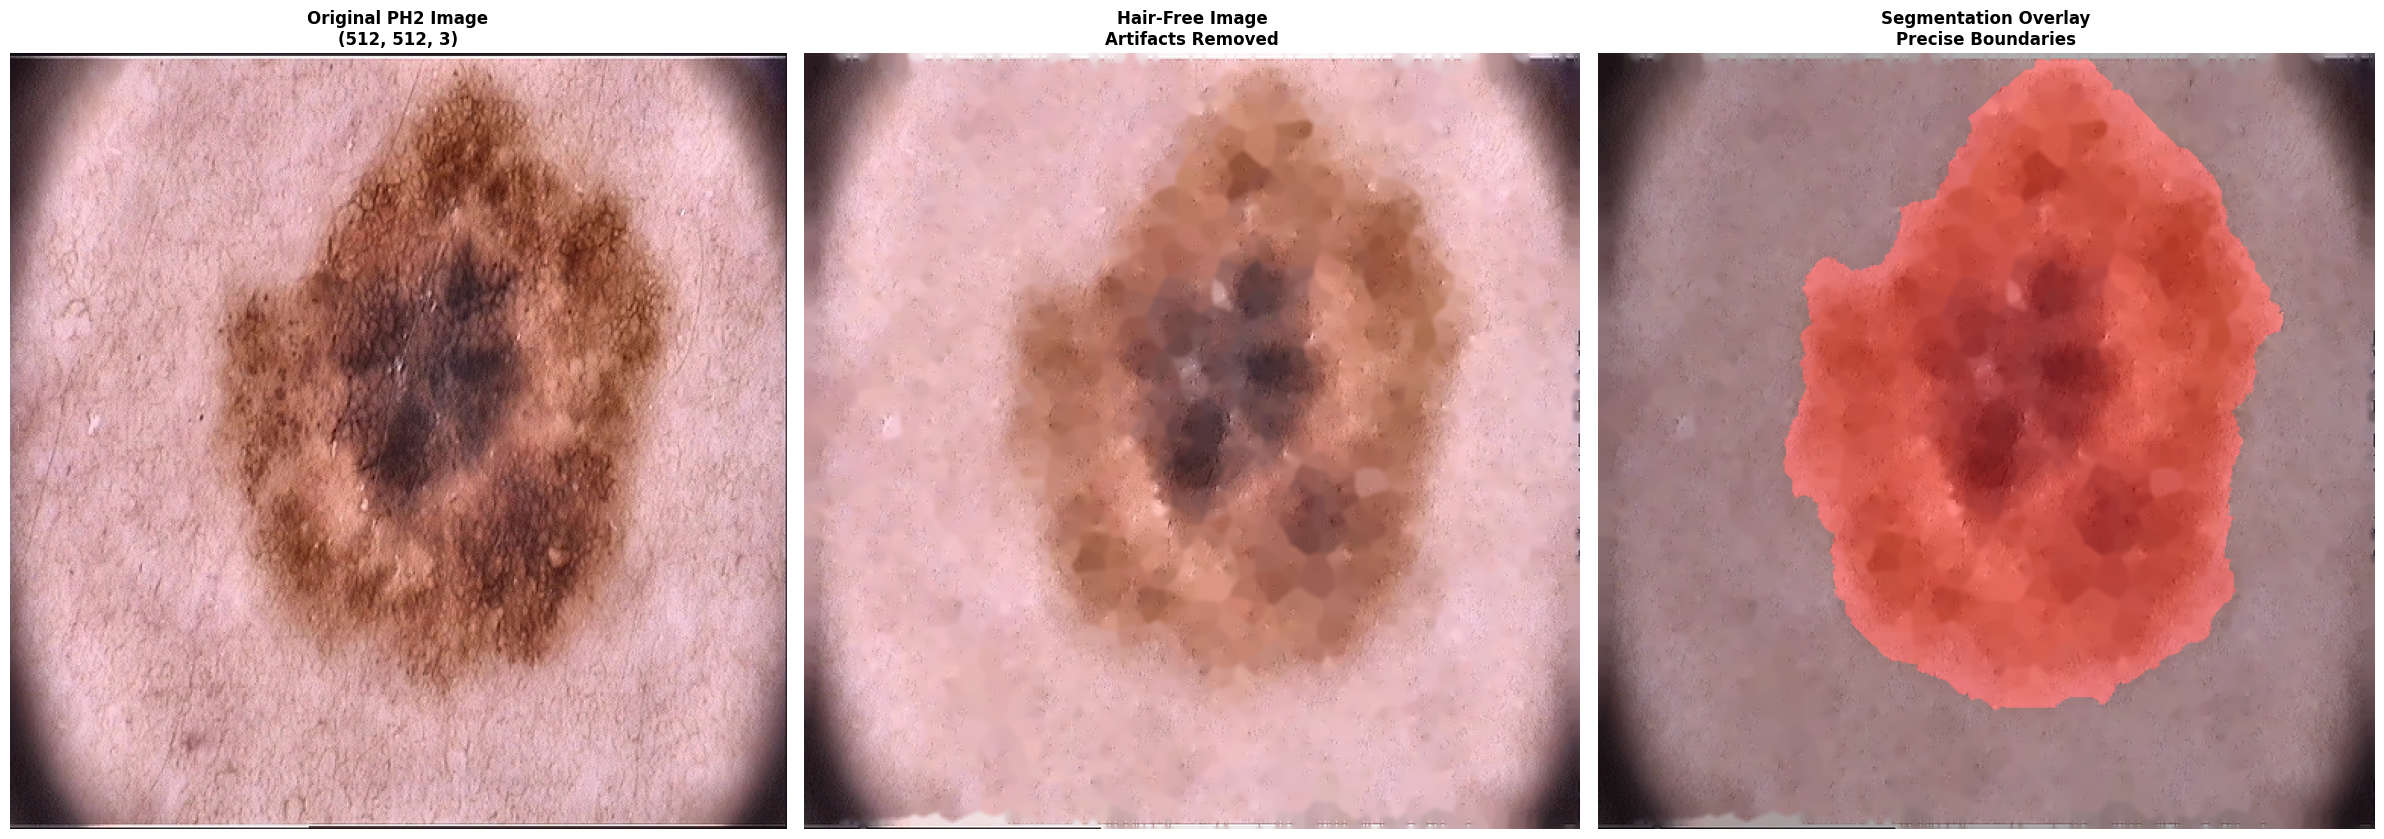

In [ ]:
def show_preprocessing_pipeline():
    """Visualize key preprocessing outputs for quick quality review.

    Panels:
        - Original PH2 image: Baseline appearance and acquisition quality (focus, illumination).
        - Hair-free image: Confirms hair removal did not distort lesion colors/edges.
        - Segmentation overlay: Quick plausibility check of the lesion boundary over the image.

    Why it matters:
        - Early visual validation reduces error propagation to feature extraction.
        - Helps detect color shifts, over-inpainting, or boundary leaks before further analysis.

    Returns:
        None. Displays figures inline.
    """
    
    if rgb_image is None or binary_mask is None:
        print(f"{Fore.RED}❌ Cannot display images - missing required data{Style.RESET_ALL}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(24, 10))

    # Original Image
    axes[0].imshow(rgb_image)
    axes[0].set_title(f'Original PH2 Image\n{rgb_image.shape}', fontweight='bold', fontsize=12)
    axes[0].axis('off')

    # Hair-Free Image
    axes[1].imshow(hair_free_image)
    axes[1].set_title('Hair-Free Image\nArtifacts Removed', fontweight='bold', fontsize=12)
    axes[1].axis('off')

    # Segmentation Overlay
    overlay = utils.create_overlay_image(hair_free_image, binary_mask)
    axes[2].imshow(overlay)
    axes[2].set_title('Segmentation Overlay\nPrecise Boundaries', fontweight='bold', fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

show_preprocessing_pipeline()


# Feature Analysis Dashboard: Asymmetry, Border, Color, Texture (LBP/GLCM)


This cell assembles qualitative visual analytics for lesion characterization:

- Asymmetry: displays mirrored-half differences to contextualize asymmetry score.

- Border: plots lesion contour to review regular vs irregular periphery.

- Color clusters: k-means visualization restricted to the lesion region.

- Texture: local binary pattern and GLCM-derived contrast summary map.



These are research measurements, not diagnostic outputs. Interpret trends alongside labels and validation metrics.

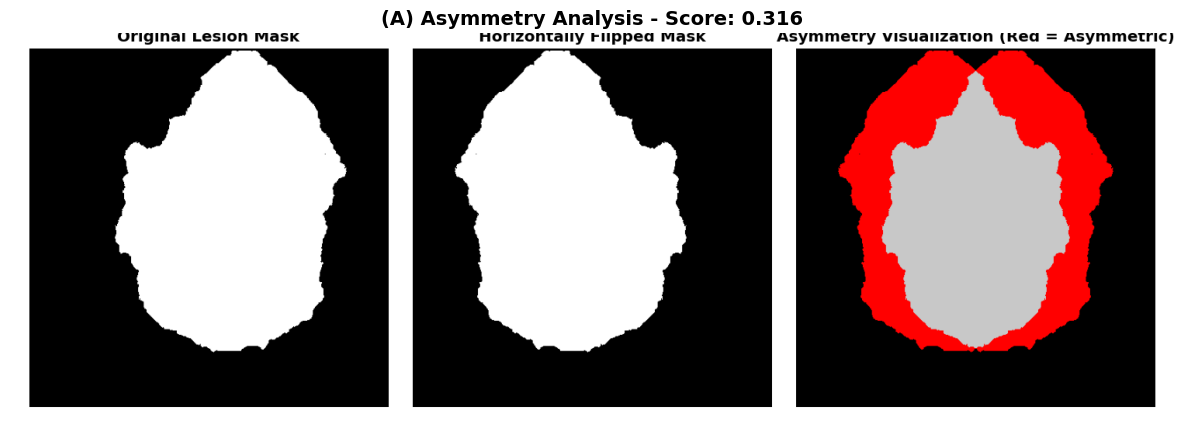

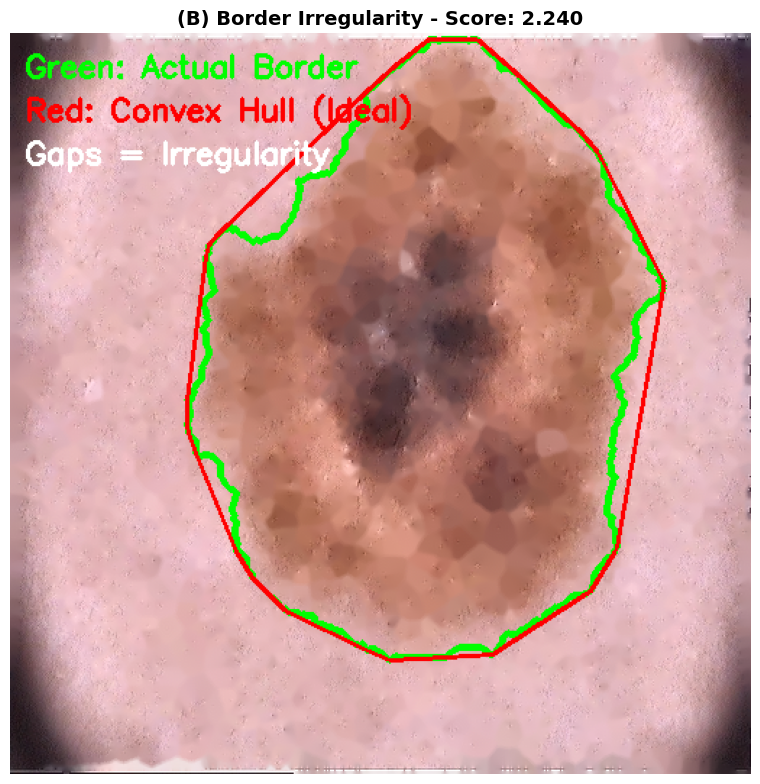

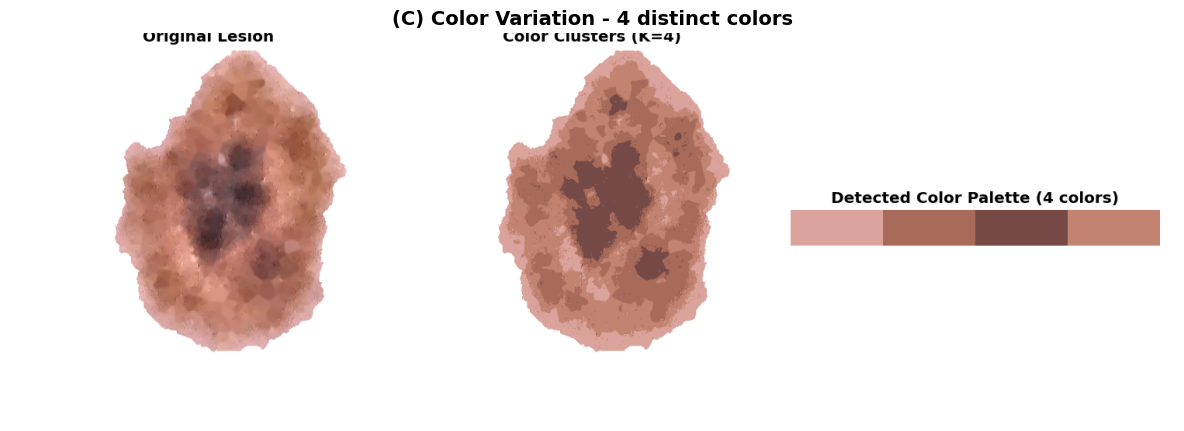

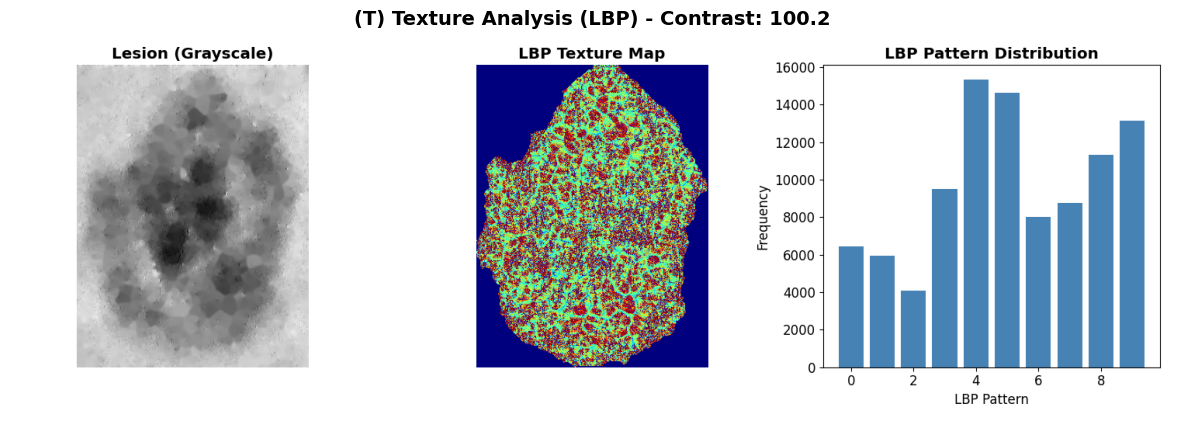

In [ ]:
def show_feature_analysis_dashboard():
    """Render qualitative analytics for ABC+T features to aid interpretation.

    Visualizations:
        - Asymmetry: Heatmap depiction of mirrored-half differences (shape irregularity context).
        - Border: Contour overlay for smooth vs irregular periphery assessment.
        - Color clusters: K-means segmentation within the lesion region to show color heterogeneity.
        - Texture: LBP map and GLCM contrast indicator of structural uniformity vs disruption.

    Inputs (global):
        - hair_free_image (np.ndarray): Preprocessed RGB image.
        - binary_mask (np.ndarray): Final lesion mask (255=lesion).
        - main_contour (np.ndarray | None): Primary contour for border visualization.
        - features (dict): Precomputed metrics (e.g., color_variation, glcm_contrast).

    Returns:
        None. Displays figures inline for each feature panel.
    """
    
    # print(f"{Fore.YELLOW}📊 Generating and displaying feature analysis (4–7)...{Style.RESET_ALL}")
    
    asymmetry_viz = utils.visualize_asymmetry(binary_mask)
    border_viz = utils.visualize_border(hair_free_image, main_contour)    
    color_variation_count = features.get('color_variation', 0)
    diameter_viz = utils.visualize_diameter(hair_free_image, binary_mask, features.get('diameter', 0))
    texture_viz = utils.visualize_texture(hair_free_image, binary_mask)
    
    if color_variation_count == 0:
        lesion_pixels = hair_free_image[binary_mask > 0]
        color_variation_count = len(np.unique(lesion_pixels.reshape(-1, 3), axis=0)) if len(lesion_pixels) > 0 else 1
    color_viz = utils.visualize_color_clusters(hair_free_image, binary_mask, color_variation_count)
    

    # Asymmetry Visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(asymmetry_viz)
    plt.title(f'(A) Asymmetry Analysis - Score: {features.get("asymmetry_score", 0):.3f}', fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Border Irregularity
    plt.figure(figsize=(12, 8))
    plt.imshow(border_viz)
    plt.title(f'(B) Border Irregularity - Score: {features.get("border_irregularity", 0):.3f}', fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Color Cluster Map
    plt.figure(figsize=(12, 8))
    plt.imshow(color_viz)
    plt.title(f'(C) Color Variation - {color_variation_count} distinct colors', fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # plt.figure(figsize=(12, 8))
    # plt.imshow(diameter_viz)
    # plt.title(f'(D) Diameter', fontweight='bold', fontsize=14)
    # plt.axis('off')
    # plt.tight_layout()
    # plt.show()

    # Texture Visualization
    plt.figure(figsize=(12, 8))
    plt.imshow(texture_viz)
    plt.title(f'(T) Texture Analysis (LBP) - Contrast: {features.get("glcm_contrast", 0):.1f}', fontweight='bold', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    show_feature_analysis_dashboard()

# Advanced DIP Comparisons: Color Constancy, GrabCut, and Feature Panels


This cell compares before/after effects and advanced features:

- Gray World color constancy vs original to reduce illumination bias.

- GrabCut refinement vs initial mask to assess boundary improvements.

- Advanced feature dashboard (FFT energy, blue-white veil proxy, etc.).



Goal: visually validate that preprocessing/segmentation improve signal without introducing artifacts. Tuning should favor specificity to avoid false positives.

ADVANCED DIP TECHNIQUES - BEFORE/AFTER COMPARISONS

1. Gray World Color Constancy Correction


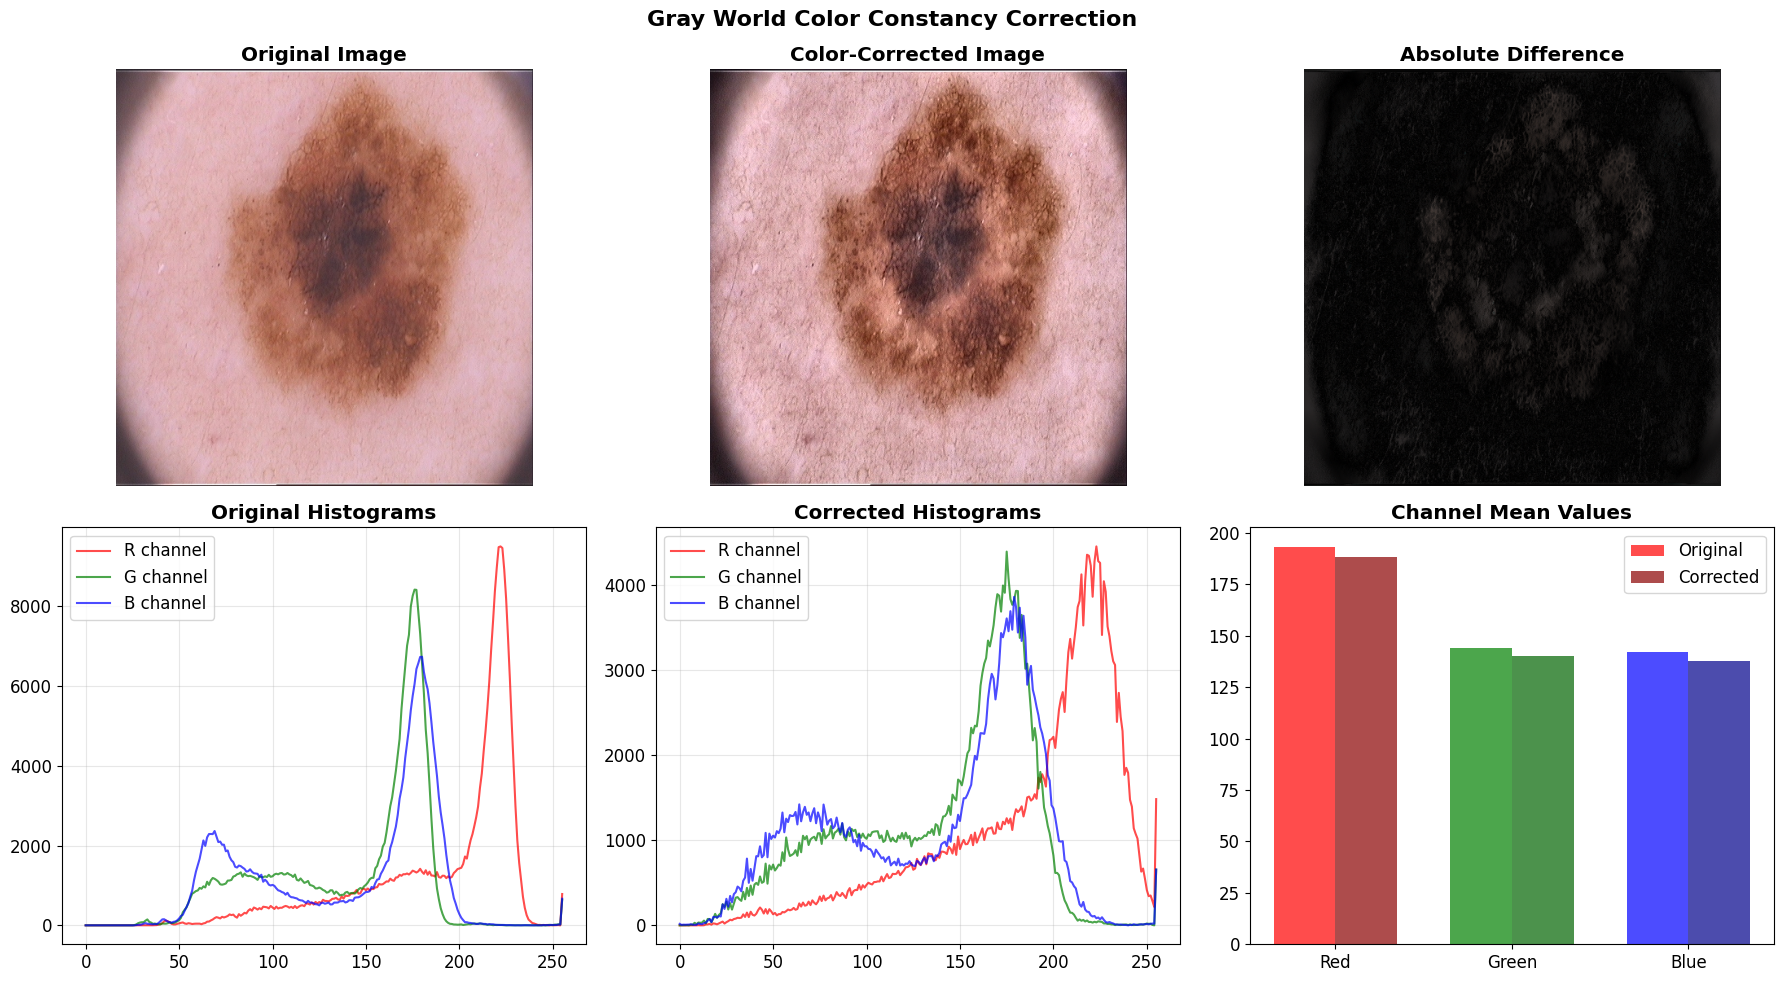


2. GrabCut Segmentation Refinement


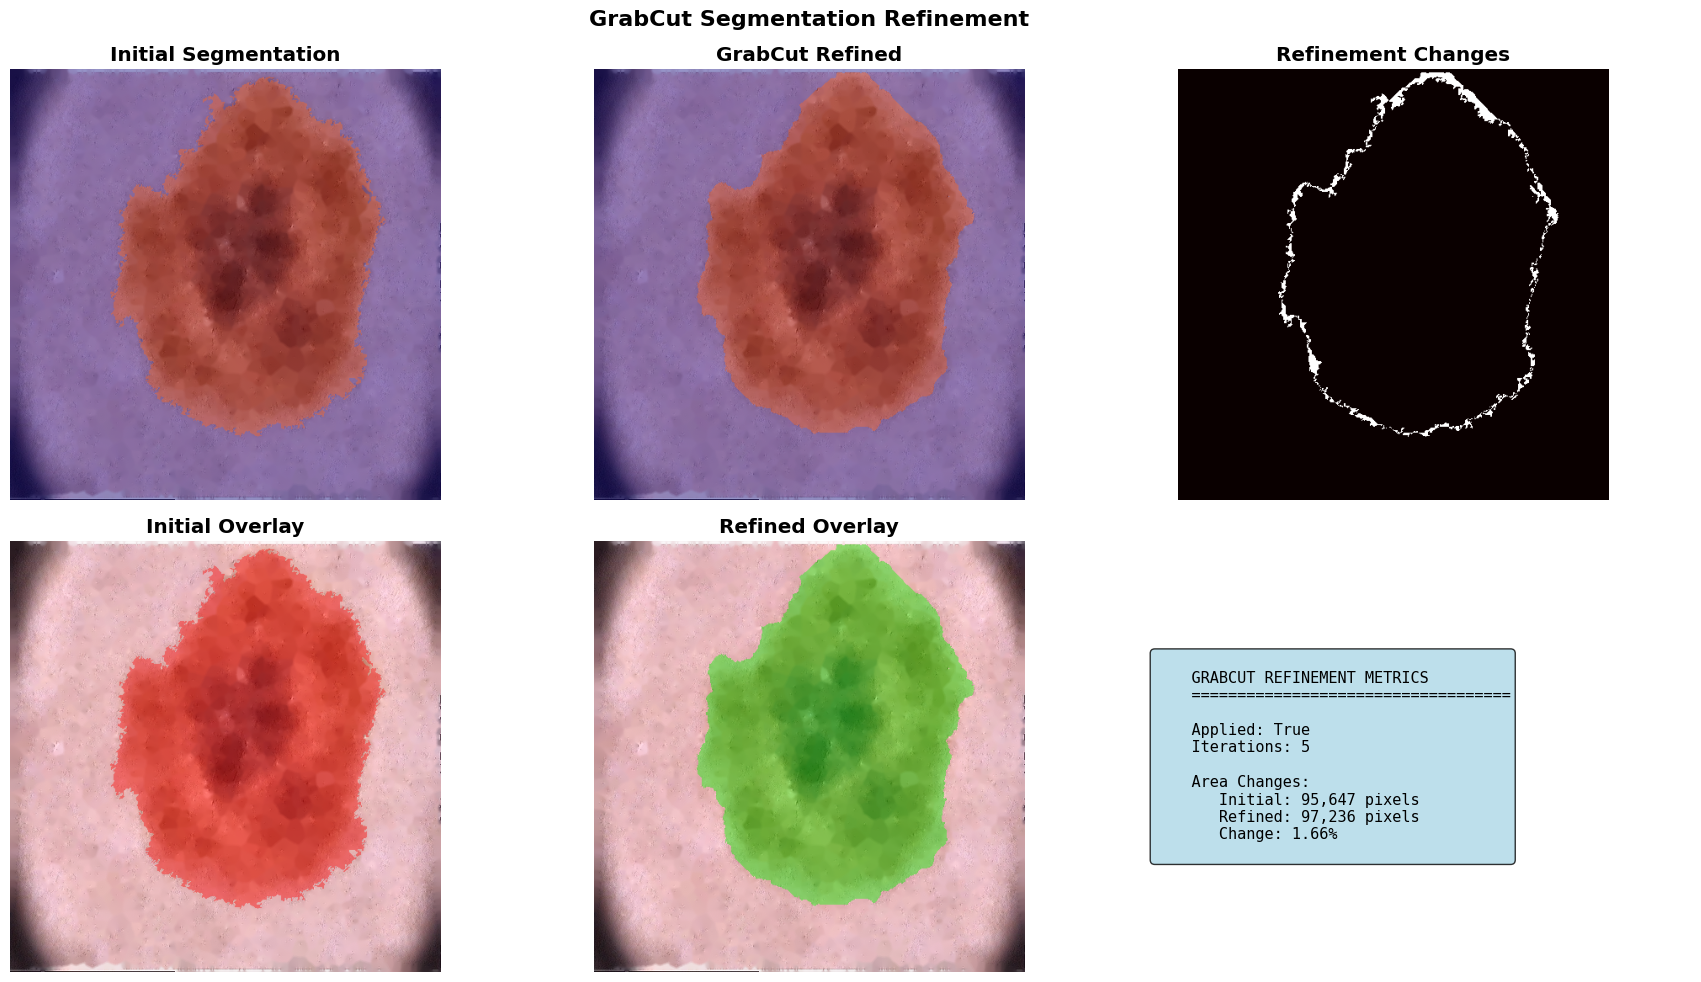


3. Advanced DIP Features Analysis


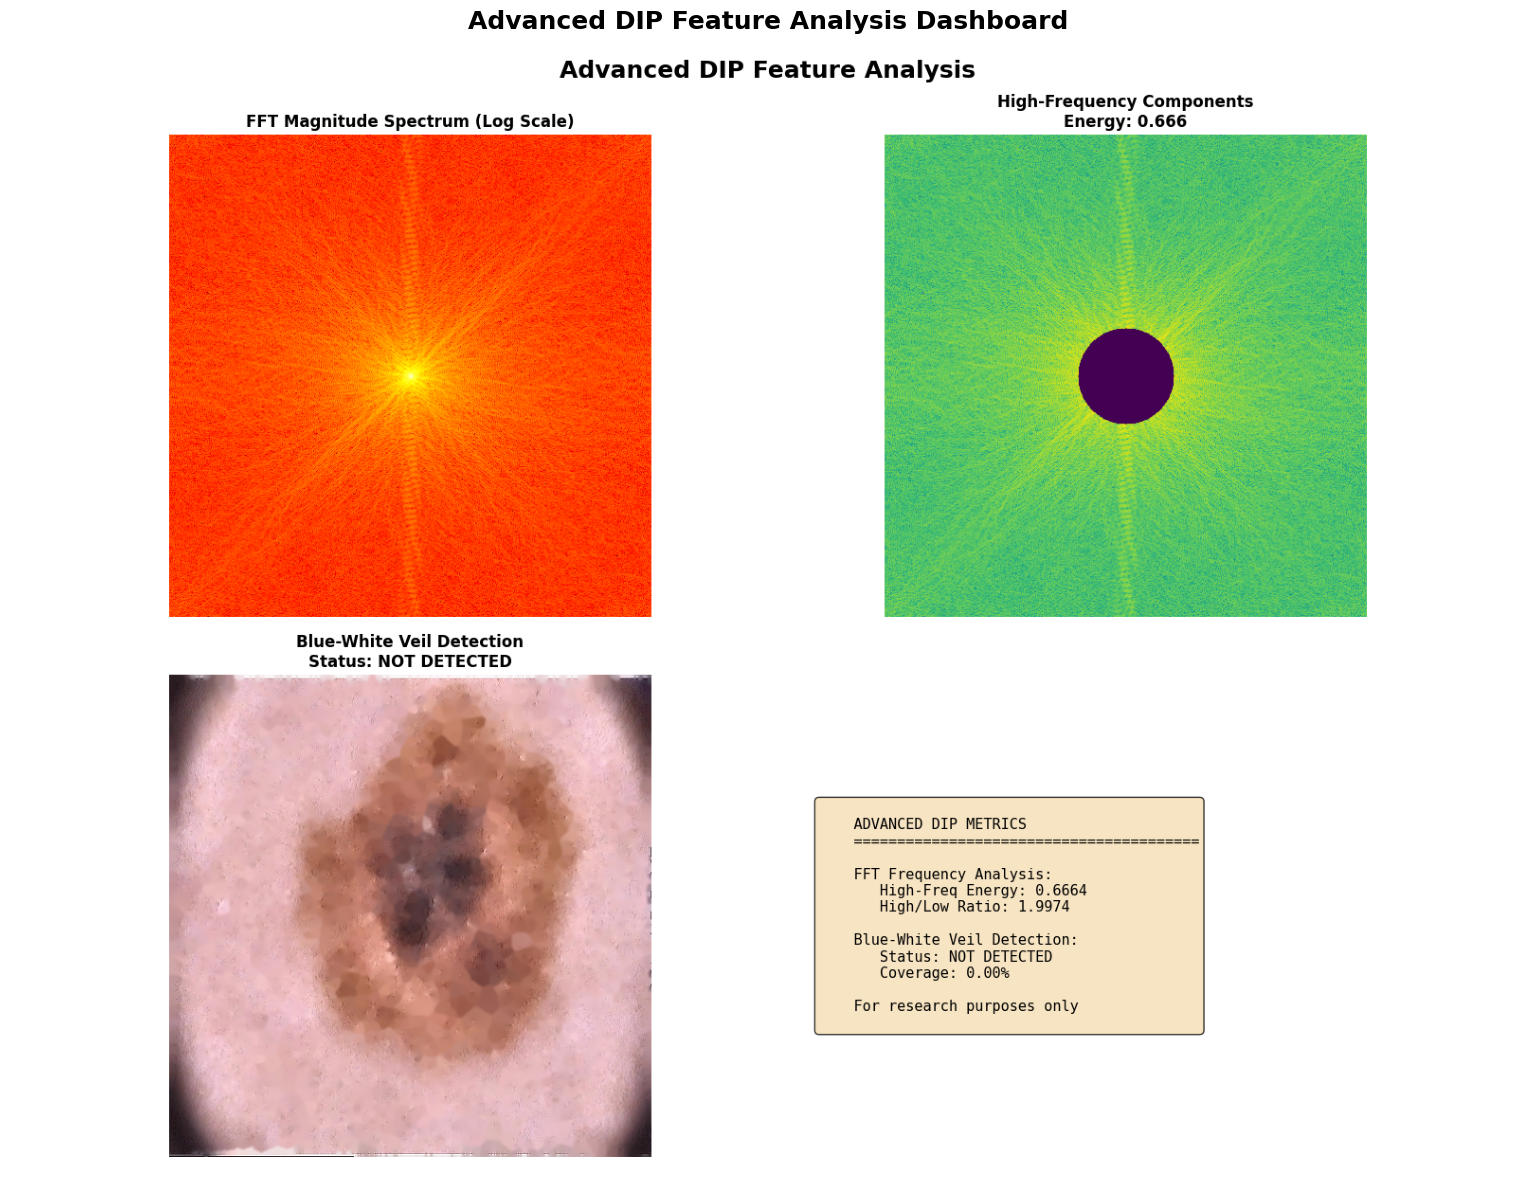


✅ All Advanced DIP visualizations complete!


In [ ]:
def show_advanced_dip_comparisons():
    """Compare key advanced DIP steps and visualize feature panels.

    Includes:
        1) Gray World color constancy vs original: reduce illumination bias without over-correction.
        2) GrabCut refinement vs initial mask: demonstrate boundary improvement and leak reduction.
        3) Advanced features dashboard: FFT high-frequency energy, BWV proxy, and related maps.

    Rationale:
        Visual checks ensure enhancements are additive (better signal/noise, cleaner boundaries) rather than destructive.
        Favor conservative tuning to avoid spurious features and inflated false positives.

    Returns:
        None. Displays comparison figures and dashboards inline.
    """
    
    print(f"{Fore.CYAN}{'='*100}{Style.RESET_ALL}")
    print(f"{Fore.YELLOW}{Style.BRIGHT}ADVANCED DIP TECHNIQUES - BEFORE/AFTER COMPARISONS{Style.RESET_ALL}")
    print(f"{Fore.CYAN}{'='*100}{Style.RESET_ALL}\n")
    
    # 1. Gray World Color Constancy Comparison
    print(f"{Fore.GREEN}1. Gray World Color Constancy Correction{Style.RESET_ALL}")
    utils.visualize_color_correction_comparison(rgb_original_resized, rgb_image)
    
    # 2. GrabCut Segmentation Refinement
    print(f"\n{Fore.GREEN}2. GrabCut Segmentation Refinement{Style.RESET_ALL}")
    utils.visualize_grabcut_comparison(hair_free_image, initial_mask, binary_mask, grabcut_metrics)
    
    # 3. Advanced DIP Features (FFT + Blue-White Veil)
    print(f"\n{Fore.GREEN}3. Advanced DIP Features Analysis{Style.RESET_ALL}")
    advanced_viz = utils.visualize_advanced_features(hair_free_image, binary_mask, features)
    
    plt.figure(figsize=(16, 12))
    plt.imshow(advanced_viz)
    plt.title('Advanced DIP Feature Analysis Dashboard', fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{Fore.CYAN}{'='*100}{Style.RESET_ALL}")
    print(f"{Fore.GREEN}✅ All Advanced DIP visualizations complete!{Style.RESET_ALL}")
    print(f"{Fore.CYAN}{'='*100}{Style.RESET_ALL}")

show_advanced_dip_comparisons()

# Segmentation Validation: Dice, IoU, Precision, Recall, F1


This cell computes objective overlap metrics against ground truth:

- Handles PH2 polarity (invert if lesion appears white) and resizes to `config.IMAGE_SIZE`.

- Computes Dice (overlap), IoU (Jaccard), Precision (FP control), Recall (FN control), and F1 (balance).

- These metrics summarize segmentation quality and support downstream confidence estimates.



Note: High-quality segmentation boosts reliability of subsequent feature analysis.

In [ ]:
# Calculate Validation Metrics 
def calculate_validation_metrics():
    """Compute overlap-based segmentation metrics against PH2 ground truth.

    Metrics:
        - Dice Coefficient: 2|A∩B| / (|A| + |B|), overlap emphasis.
        - IoU (Jaccard): |A∩B| / |A∪B|, stricter overlap.
        - Precision: TP / (TP + FP), background leak control.
        - Recall: TP / (TP + FN), lesion miss control.
        - F1 Score: Harmonic mean of precision and recall.

    Steps:
        - Load GT mask, correct polarity if needed (PH2 peculiarity), and resize to `config.IMAGE_SIZE`.
        - Compare with `binary_mask` to derive counts and compute metrics.

    Returns:
        bool: True on success, False if GT is unavailable.

    Notes:
        - Quality of segmentation strongly influences downstream feature reliability.
        - All results are research signals and require validation on labeled cohorts.
    """
    global dice_score, iou, f1_score, precision, recall, gt_mask_resized
    
    # Load and process ground truth mask
    gt_mask = cv2.imread(ground_truth_mask_path, cv2.IMREAD_GRAYSCALE)
    if gt_mask is None:
        print(f"{Fore.RED}❌ Could not load ground truth mask{Style.RESET_ALL}")
        return False
    
    # Handle potential mask inversion (PH2 dataset specific)
    lesion_pixels_gt = np.sum(gt_mask > 128)
    background_pixels_gt = np.sum(gt_mask <= 128)
    
    # PH2 dataset uses BLACK for lesion, WHITE for background
    # We need to invert to match our convention: WHITE for lesion, BLACK for background
    if lesion_pixels_gt > background_pixels_gt:
        # If more pixels are bright (white), then lesion is white - need to invert
        gt_mask = 255 - gt_mask
        print(f"{Fore.YELLOW}🔄 Inverted ground truth mask (PH2 uses black for lesion){Style.RESET_ALL}")
    
    # Resize to match our processing size
    gt_mask_resized = cv2.resize(gt_mask, config.IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)
    
    # Calculate comprehensive performance metrics
    dice_score = utils.calculate_dice_coefficient(gt_mask_resized, binary_mask)
    
    intersection = np.sum((gt_mask_resized > 0) & (binary_mask > 0))
    union = np.sum((gt_mask_resized > 0) | (binary_mask > 0))
    iou = intersection / union if union > 0 else 0
    
    # Calculate precision and recall
    true_positives = intersection
    false_positives = np.sum((binary_mask > 0) & (gt_mask_resized == 0))
    false_negatives = np.sum((gt_mask_resized > 0) & (binary_mask == 0))
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
calculate_validation_metrics()


# ABC+T Feature Report and Advanced Metrics Interpretation


This cell prints a structured table summarizing normalized feature scores:

- ABC+T: Asymmetry, Border irregularity, Color variation, Texture contrast (GLCM).

- Adds texture homogeneity for nuance and reports FFT metrics and BWV proxy.

- Uses conservative language; values are research signals and not diagnostic.



Tip: Track changes in these scores when tuning preprocessing or segmentation—they should move consistently on known benign vs malignant sets.

In [ ]:
def display_abcd_and_texture_report():
    """Print a structured ABC+T feature summary and advanced metrics.

    What it shows:
        - ABC+T table: Asymmetry, Border irregularity, Color variation, Texture contrast (GLCM).
        - Texture homogeneity: Additional context on structural uniformity (0-1).
        - FFT high-frequency energy + high/low ratio: Fine-scale texture richness (research signal).
        - Blue-White Veil (BWV) proxy: Conservative heuristic; not diagnostic.

    Normalization/Scoring:
        - Uses normalized scores (0-1) for each component to provide a comparable risk proxy.
        - Values are research-oriented and should be interpreted alongside ground truth and segmentation quality.

    Returns:
        None. Prints a human-readable report with conservative, transparent language.
    """
    
    if features is None:
        print(f"{Fore.RED}❌ Cannot display report - features not available{Style.RESET_ALL}")
        return

    # Extract raw features (excluding Diameter)
    asymmetry_raw = features.get('asymmetry', 0)  # Raw: 0.0-1.0
    border_raw = features.get('border_irregularity', 1.0)  # Raw: 1.0-10.0
    color_count = int(features.get('color_variation', 1))  # Raw: 1-6
    texture_contrast = features.get('glcm_contrast', 0)  # Raw: 0-300+
    texture_homogeneity = features.get('glcm_homogeneity', 0)  # Raw: 0-1
    
    # Get normalized scores (0-1 range)
    asymmetry_score = features.get('asymmetry_score', 0)
    border_score = features.get('border_irregularity_score', 0)
    color_score = features.get('color_variation_score', 0)
    texture_score = features.get('texture_contrast_score', 0)

    # Risk values (same as normalized scores)
    asymmetry_risk = asymmetry_score
    border_risk = border_score
    color_risk = color_score
    texture_risk = texture_score
    
    def get_risk_level(risk_score):
        if risk_score < 0.3:
            return f"{Fore.GREEN}LOW{Style.RESET_ALL}"
        elif risk_score < 0.7:
            return f"{Fore.YELLOW}MODERATE{Style.RESET_ALL}"
        else:
            return f"{Fore.RED}HIGH{Style.RESET_ALL}"

    # ABC+T Feature Summary Table (Diameter excluded)
    abcd_data = [
        ["Asymmetry", f"{asymmetry_raw:.3f} (0-1)", f"{asymmetry_risk:.3f}", get_risk_level(asymmetry_risk), "Irregular shape suggests possible malignancy" if asymmetry_risk > 0.5 else "Regular symmetry (benign tendency)"],
        ["Border", f"{border_raw:.3f} (1-10)", f"{border_risk:.3f}", get_risk_level(border_risk), "Irregular border may indicate malignancy" if border_risk > 0.5 else "Well-defined border (benign tendency)"],
        ["Color", f"{color_count} colors (1-6)", f"{color_risk:.3f}", get_risk_level(color_risk), "Multiple colors (suspicious)" if color_count >= 4 else "Few colors (benign)"],
        ["Texture (GLCM)", f"{texture_contrast:.1f} (0-300)", f"{texture_risk:.3f}", get_risk_level(texture_risk), "High contrast (irregular texture)" if texture_contrast > 100 else "Low contrast (uniform)"],
    ]

    print(f"\n{Fore.YELLOW}{Style.BRIGHT}ABC+T RULE ASSESSMENT{Style.RESET_ALL}")
    print(f"{Fore.CYAN}Note: Diameter excluded (requires dataset-specific calibration){Style.RESET_ALL}")
    print(tabulate(abcd_data, headers=["Feature", "Score", "Risk Value", "Risk Level", "Clinical Observation"], tablefmt="fancy_grid"))
    print()

    # Texture Details
    print(f"{Fore.GREEN}Texture Homogeneity:{Style.RESET_ALL} {texture_homogeneity:.3f} (0-1 scale)")
    print(f"{Fore.CYAN}Observation:{Style.RESET_ALL} {'High homogeneity = uniform tissue (benign)' if texture_homogeneity > 0.5 else 'Low homogeneity = irregular pattern (suspicious)'}")
    print()
    
    # Advanced DIP Features Section
    print(f"{Fore.YELLOW}{Style.BRIGHT}ADVANCED DIP FEATURES{Style.RESET_ALL}")
    print(f"{Fore.CYAN}{'-'*100}{Style.RESET_ALL}")
    
    # FFT Frequency Analysis
    fft_high_freq = features.get('fft_high_frequency_energy', 0)
    fft_ratio = features.get('fft_high_low_ratio', 0)
    print(f"{Fore.GREEN}FFT High-Frequency Energy:{Style.RESET_ALL} {fft_high_freq:.4f} (0-1 scale)")
    print(f"{Fore.GREEN}FFT High/Low Ratio:{Style.RESET_ALL} {fft_ratio:.4f}")
    print(f"{Fore.CYAN}Interpretation:{Style.RESET_ALL} {'⚠️  High texture complexity (irregular)' if fft_high_freq > 0.5 else '✅ Smooth texture pattern'}")
    print()
    
    # Blue-White Veil Detection
    bwv_present = features.get('blue_white_veil_present', 0)
    bwv_coverage = features.get('blue_white_veil_coverage_percentage', 0)
    bwv_confidence = features.get('blue_white_veil_confidence', 0)
    print(f"{Fore.GREEN}Blue-White Veil Status:{Style.RESET_ALL} {'🚨 DETECTED' if bwv_present else '✅ NOT DETECTED'}")
    print(f"{Fore.GREEN}Coverage:{Style.RESET_ALL} {bwv_coverage:.2f}% of lesion area")
    print(f"{Fore.GREEN}Confidence:{Style.RESET_ALL} {bwv_confidence:.3f} (0-1 scale)")
    
    if bwv_present:
        print(f"{Fore.RED}Clinical Note:{Style.RESET_ALL} Blue-white veil is a melanoma indicator")
    else:
        print(f"{Fore.GREEN}Clinical Note:{Style.RESET_ALL} No blue-white veil detected (benign sign)")
    print()

display_abcd_and_texture_report()


ABC+T RULE ASSESSMENT
Note: Diameter excluded (requires dataset-specific calibration)
╒════════════════╤════════════════╤══════════════╤══════════════╤══════════════════════════════════════════╕
│ Feature        │ Score          │   Risk Value │ Risk Level   │ Clinical Observation                     │
╞════════════════╪════════════════╪══════════════╪══════════════╪══════════════════════════════════════════╡
│ Asymmetry      │ 0.158 (0-1)    │        0.316 │ MODERATE     │ Regular symmetry (benign tendency)       │
├────────────────┼────────────────┼──────────────┼──────────────┼──────────────────────────────────────────┤
│ Border         │ 2.240 (1-10)   │        0.62  │ MODERATE     │ Irregular border may indicate malignancy │
├────────────────┼────────────────┼──────────────┼──────────────┼──────────────────────────────────────────┤
│ Color          │ 4 colors (1-6) │        0.6   │ MODERATE     │ Multiple colors (suspicious)             │
├────────────────┼────────────────┼──────

# Overall Risk (ABC+T) and Segmentation Quality Summary


This cell aggregates normalized ABC+T scores into a simple overall risk proxy:

- Averages Asymmetry, Border, Color, Texture normalized values (Diameter excluded unless calibrated).

- Maps overlap metrics (Dice/IoU/F1/Precision/Recall) to qualitative bands for readability.

- Prints a conservative summary intended for research review, not clinical decisions.



Caution: Overall risk depends on the quality of segmentation and the dataset. Calibrate on labeled sets and monitor for shifts when tuning.

In [ ]:
def display_segmentation_and_overall_risk():
    """Summarize segmentation quality and compute an overall ABC+T risk proxy.

    Components:
        - Segmentation quality: Dice, IoU, F1, Precision, Recall mapped to qualitative bands.
        - Overall risk: Mean of normalized ABC+T scores (Diameter excluded unless calibrated).
        - Confidence: Heuristic text guidance based on Dice ranges.

    Why a proxy:
        - A simple aggregate aids quick review but should not be treated as diagnostic.
        - Always cross-check with labeled data and visual panels.

    Returns:
        None. Prints a compact, readable summary.
    """

    # Calculate overall risk using ABC+T (excluding Diameter)
    asymmetry_risk = features.get('asymmetry_score', 0)
    border_risk = features.get('border_irregularity_score', 0)
    color_risk = features.get('color_variation_score', 0)
    texture_risk = features.get('texture_contrast_score', 0)
    
    # Overall risk = average of ABC+T scores
    overall_risk = (asymmetry_risk + border_risk + color_risk + texture_risk) / 4.0
    
    def get_segmentation_quality(score):
        if score >= 0.9:
            return f"{Fore.GREEN}EXCELLENT{Style.RESET_ALL}"
        elif score >= 0.8:
            return f"{Fore.GREEN}VERY GOOD{Style.RESET_ALL}"
        elif score >= 0.7:
            return f"{Fore.YELLOW}GOOD{Style.RESET_ALL}"
        elif score >= 0.5:
            return f"{Fore.YELLOW}FAIR{Style.RESET_ALL}"
        else:
            return f"{Fore.RED}POOR{Style.RESET_ALL}"

    def get_analysis_confidence(dice_score):
        if dice_score >= 0.9:
            return f"{Fore.GREEN}HIGH{Style.RESET_ALL} (Excellent segmentation)"
        elif dice_score >= 0.8:
            return f"{Fore.GREEN}HIGH{Style.RESET_ALL} (Very good segmentation)"
        elif dice_score >= 0.7:
            return f"{Fore.YELLOW}MODERATE{Style.RESET_ALL} (Good segmentation)"
        elif dice_score >= 0.5:
            return f"{Fore.YELLOW}MODERATE{Style.RESET_ALL} (Fair segmentation)"
        else:
            return f"{Fore.RED}LOW{Style.RESET_ALL} (Poor segmentation)"

    # Determine overall risk level
    if overall_risk < 0.3:
        risk_level, risk_color = "LOW", Fore.GREEN
    elif overall_risk < 0.7:
        risk_level, risk_color = "MODERATE", Fore.YELLOW
    else:
        risk_level, risk_color = "HIGH", Fore.RED

    # Segmentation Quality Section
    seg_data = [
        ["Dice Coefficient", f"{dice_score:.3f}", get_segmentation_quality(dice_score)],
        ["IoU (Jaccard)", f"{iou:.3f}", get_segmentation_quality(iou)],
        ["F1 Score", f"{f1_score:.3f}", get_segmentation_quality(f1_score)],
        ["Precision", f"{precision:.3f}", get_segmentation_quality(precision)],
        ["Recall", f"{recall:.3f}", get_segmentation_quality(recall)]
    ]
    
    print(f"\n{Fore.YELLOW}{Style.BRIGHT}SEGMENTATION QUALITY METRICS{Style.RESET_ALL}")
    print(tabulate(seg_data, headers=["Metric", "Value", "Quality"], tablefmt="fancy_grid"))
    print()

    # Overall Risk Summary
    print(f"{Fore.YELLOW}{Style.BRIGHT}OVERALL RISK ASSESSMENT (ABC+T){Style.RESET_ALL}")
    print(f"{Fore.CYAN}{'-'*100}{Style.RESET_ALL}")
    print(f"{Fore.GREEN}Overall Risk Level:{Style.RESET_ALL} {risk_color}{Style.BRIGHT}{risk_level}{Style.RESET_ALL}")
    print(f"{Fore.GREEN}Combined Risk Score:{Style.RESET_ALL} {overall_risk:.3f} (0-1 scale)")
    print(f"{Fore.GREEN}Segmentation Confidence:{Style.RESET_ALL} {get_analysis_confidence(dice_score)}")
    print(f"{Fore.CYAN}Note:{Style.RESET_ALL} Risk calculated from Asymmetry, Border, Color, and Texture only")
    print()

display_segmentation_and_overall_risk()


SEGMENTATION QUALITY METRICS
╒══════════════════╤═════════╤═══════════╕
│ Metric           │   Value │ Quality   │
╞══════════════════╪═════════╪═══════════╡
│ Dice Coefficient │   0.939 │ EXCELLENT │
├──────────────────┼─────────┼───────────┤
│ IoU (Jaccard)    │   0.884 │ VERY GOOD │
├──────────────────┼─────────┼───────────┤
│ F1 Score         │   0.939 │ EXCELLENT │
├──────────────────┼─────────┼───────────┤
│ Precision        │   0.885 │ VERY GOOD │
├──────────────────┼─────────┼───────────┤
│ Recall           │   0.999 │ EXCELLENT │
╘══════════════════╧═════════╧═══════════╛

OVERALL RISK ASSESSMENT (ABC+T)
----------------------------------------------------------------------------------------------------
Overall Risk Level: MODERATE
Combined Risk Score: 0.509 (0-1 scale)
Segmentation Confidence: HIGH (Excellent segmentation)
Note: Risk calculated from Asymmetry, Border, Color, and Texture only

